In [1]:
# Libraries, modules
import soundfile as sf
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import peak_local_max

rec_filename = "000_1.392_seq.flac"

# Read full audio recording
data, fs = sf.read("./signal_sequences/"+rec_filename)
l_ch = data[:,0] # Left channel
#r_ch = data[:,0] # Right channel

chunk_no = 0

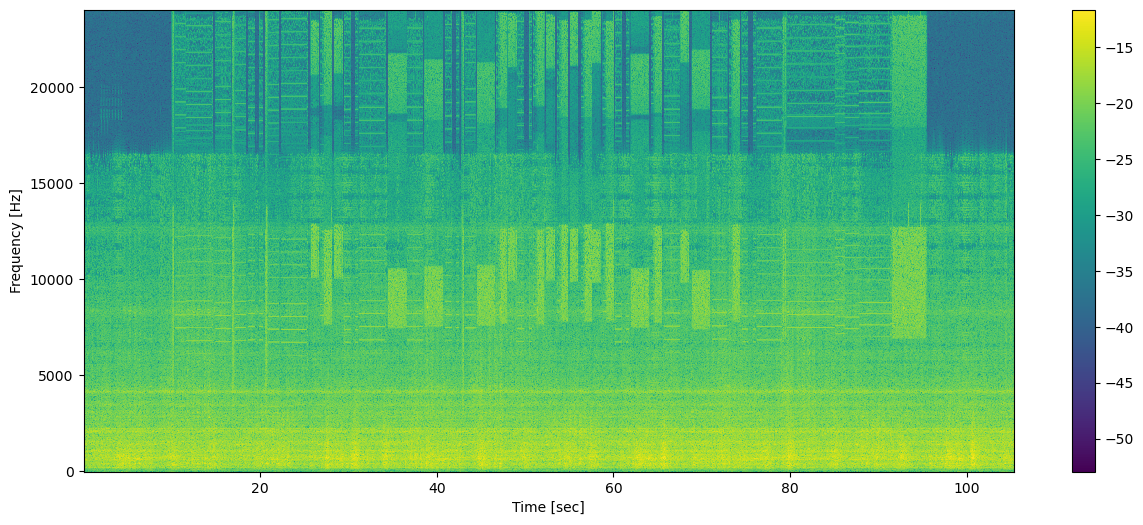

In [84]:
## Generate Spectrogram (2D FFT)
win_size = 2048 # Seems to work better than 2048 (higher cross correlation coefficients)
f, t, spectrogram = signal.spectrogram(l_ch, fs, window='hann', nperseg=win_size, noverlap=int(win_size*0.75))

# Plot spectrogram (in dB)
plt.figure(figsize=(15,6))
plt.pcolormesh(t, f, np.log(spectrogram))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

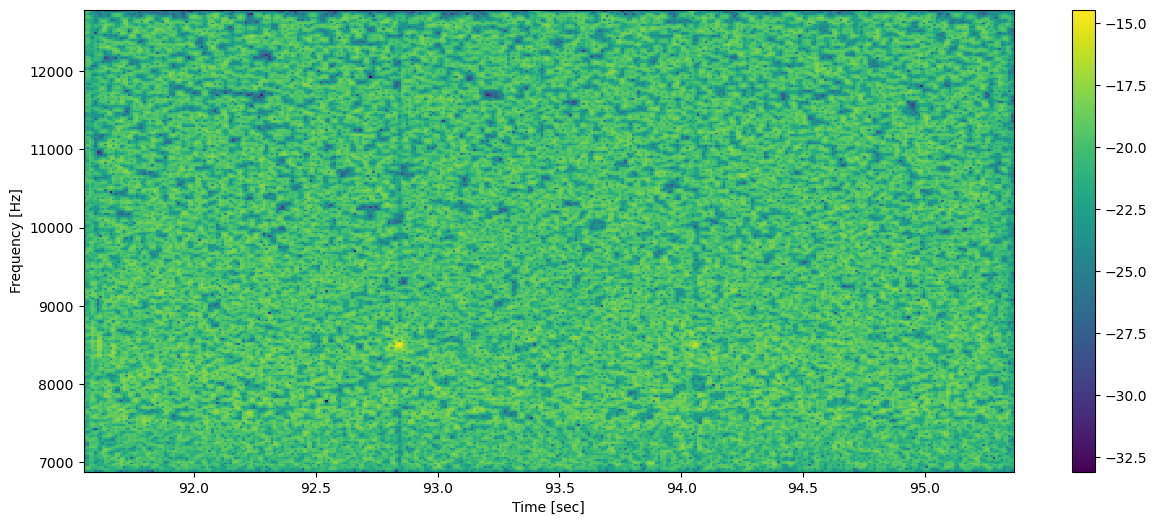

In [78]:
## Crop to signal
# Frequency range
f_low = 6900 # Hz
f_high = 12800 # Hz
f_0 = int(f_low*len(f)/np.max(f))
f_1 = int(f_high*len(f)/np.max(f))
spec_crop_f = spectrogram[f_0:f_1,:]

# Time range
t_start = 91.55
t_end = 95.37
t_0 = np.searchsorted(t, t_start)  # Find the index of the start time
t_1 = np.searchsorted(t, t_end)    # Find the index of the end time
spec_crop_ft = spec_crop_f[:, t_0:t_1]

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.pcolormesh(t[t_0:t_1], f[f_0:f_1], np.log(spec_crop_ft))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [80]:
np.savetxt('signal_samples/end_signal_48k-2048.csv', spec_crop_ft, delimiter=',')

In [81]:
# Load end signal
endsig = np.genfromtxt('signal_samples/end_signal_48k-2048.csv', delimiter=',')

(252, 358)

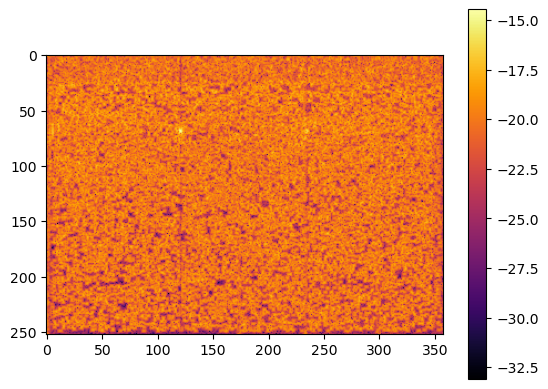

In [82]:
# Define end signal array (plot is flipped vertically)

end_signal = np.log(endsig).astype(np.float32)
plt.imshow(end_signal, cmap="inferno")
plt.colorbar()
end_signal.shape

(683, 42235)

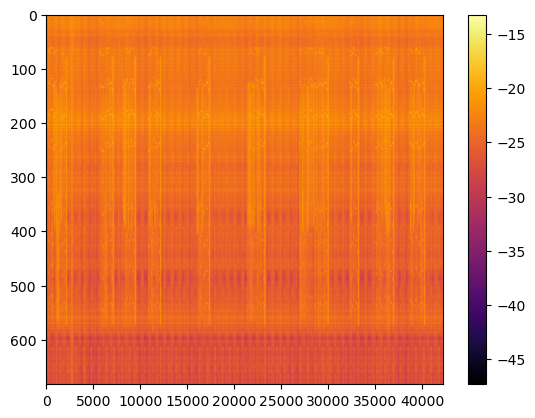

In [7]:
# Define recording array  (plot is flipped vertically)
 
recording = np.log(spec_crop).astype(np.float32)
plt.imshow(recording, aspect='auto', cmap="inferno")
plt.colorbar()
recording.shape

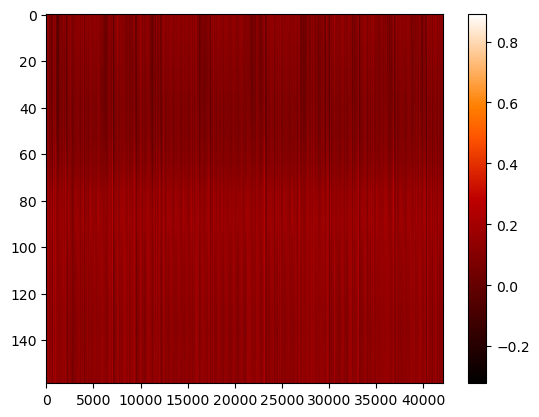

In [8]:
## Search based on OpenCV match template, very fast

correlation_opencv = cv2.matchTemplate(recording, end_signal, cv2.TM_CCOEFF_NORMED)

plt.imshow(correlation_opencv, aspect='auto', cmap="gist_heat")
plt.colorbar()

In [34]:
## Find and print local maxima locations
dist = correlation_opencv.shape[0]//4
local_maxima = peak_local_max(correlation_opencv, min_distance=dist, threshold_abs=0.5)
print(local_maxima)

[[   72  2156]
 [   72 17354]
 [   72 33234]
 [   72 23243]
 [   72  7099]
 [   72 12138]
 [   72  9479]
 [   72 40268]
 [   72 36946]
 [   72 29976]]


In [42]:
chunk_no = 1

In [43]:
## Divide audio chunk into single sequences

# Sort by time sample
sorted_indices = np.argsort(local_maxima[:, 1])
sorted_local_maxima = local_maxima[sorted_indices]

# The "small" end signal sample is about 5 s long, and I'm adding another 10 s of buffer after it
# The local maxima correspond to FFT samples, and there is a factor of 2 correction, I think it's due to the FFT overlap
i = 0
end_sample = (sorted_local_maxima[:, 1]/2*win_size + 2.5*fs + 10*fs).astype(int)
start_sample = end_sample + 1
start_sample = np.delete(start_sample, -1)
start_sample = np.insert(start_sample, 0, 0)
timing = np.column_stack((start_sample, end_sample))
timing = timing + chunk_no*20*60*fs
print(timing)

[[ 57600000  62615488]
 [ 62615489  72738752]
 [ 72738753  77612992]
 [ 77612993  83058624]
 [ 83058625  93740992]
 [ 93740993 105801664]
 [105801665 119590848]
 [119590849 126263232]
 [126263233 133865408]
 [133865409 140668864]]


In [ ]:
#